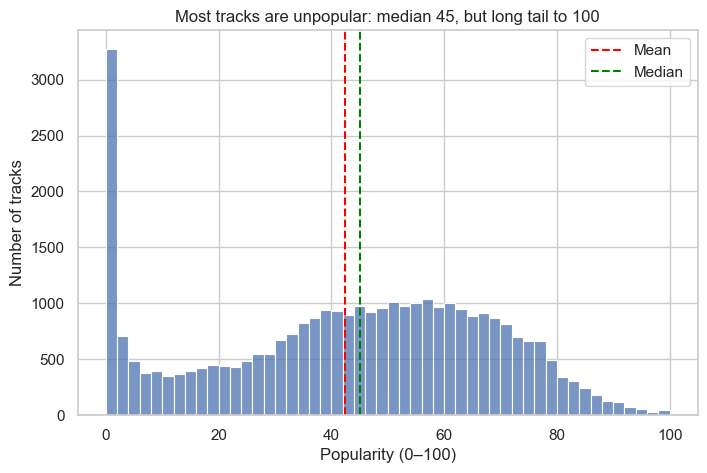

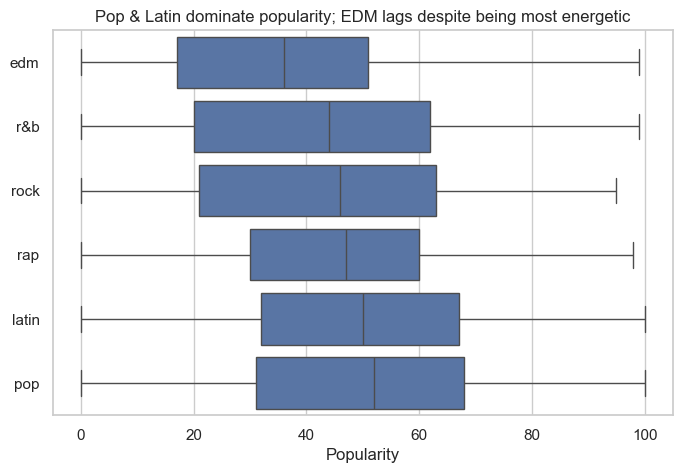

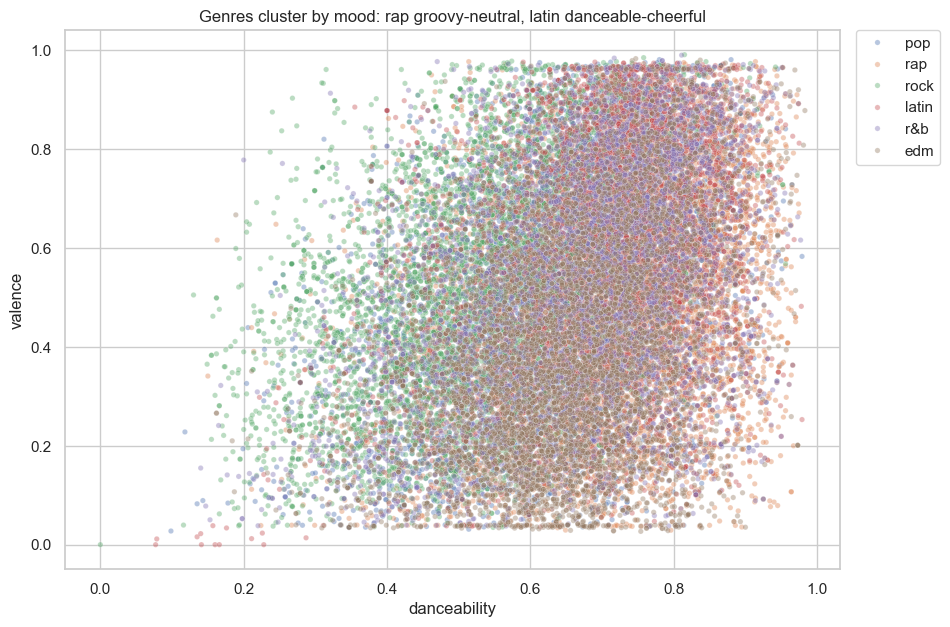

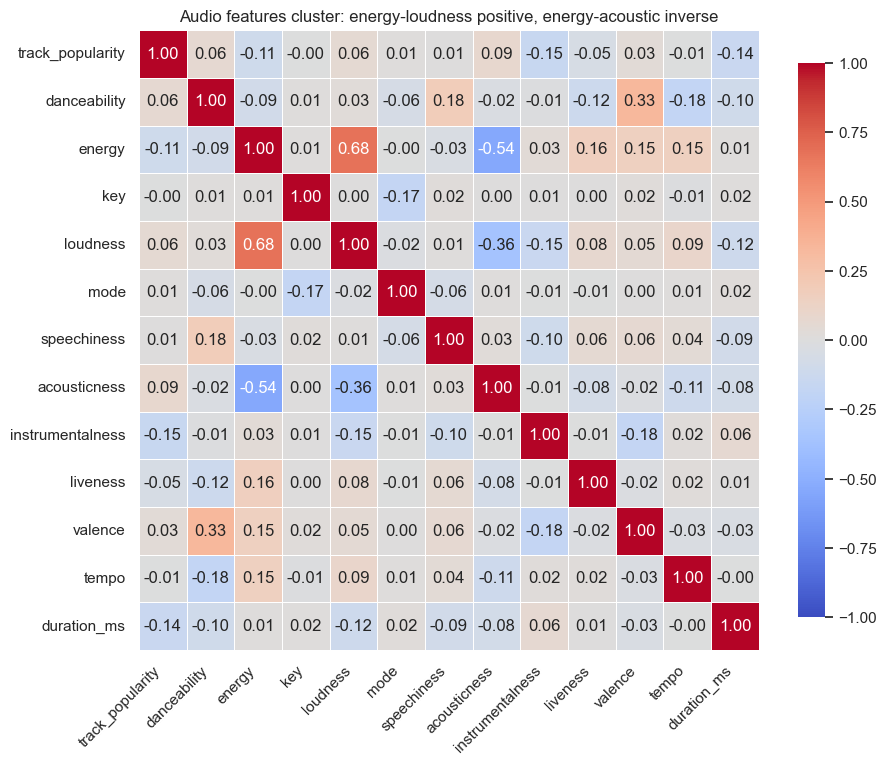

In [116]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

PLOTS_DIR = Path("../plots")           # relatif dari notebooks/
PLOTS_DIR.mkdir(exist_ok=True)         # bikin folder kalau belum ada

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/spotify_songs.csv") 

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
  data=df,
  bins=50,
  x="track_popularity",
  ax=ax
) 
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("Number of tracks")
ax.axvline(df["track_popularity"].mean(), label="Mean", color="red", linestyle="--")
ax.axvline(df["track_popularity"].median(), label="Median", color="green", linestyle="--")
ax.legend()
ax.set_title("Most tracks are unpopular: median 45, but long tail to 100")
fig.savefig(PLOTS_DIR / "01_popularity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby("playlist_genre")["track_popularity"].median().sort_values(ascending=True).index 
sns.boxplot(
  data=df,
  x="track_popularity",
  y="playlist_genre",
  ax=ax,
  order=order, 
)
ax.set_title("Most songs are unpopular — distribution heavily right-skewed\n(mean > median signals long tail of unpopular tracks)")
ax.set_xlabel("Popularity")
ax.set_ylabel("")  # genre udah jelas dari label
ax.set_title("Pop & Latin dominate popularity; EDM lags despite being most energetic")
fig.savefig(PLOTS_DIR / "02_popularity_per_genre_box.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
  data=df,
  x="danceability",
  y="valence",
  hue="playlist_genre", 
  alpha=0.4, 
  ax=ax,
  s=15
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_title("Genres cluster by mood: rap groovy-neutral, latin danceable-cheerful")
fig.savefig(PLOTS_DIR / "03_audio_features_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 9))
features = df.select_dtypes(include="number").columns
corr = df[features].corr()

sns.heatmap(
  data=corr,
  ax=ax,
  vmin=-1, vmax=1,
  annot=True,
  center=0,
  cmap="coolwarm", 
  fmt=".2f",
  square=True,           # paksa sel jadi square
  linewidths=0.5,        # garis pemisah tipis biar grid lebih jelas
  cbar_kws={"shrink": 0.8},  # colorbar lebih kecil
)
ax.set_title("Audio features cluster: energy-loudness positive, energy-acoustic inverse")
plt.xticks(rotation=45, ha="right")  # rotasi label x biar nggak overlap
fig.savefig(PLOTS_DIR / "04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()